what was wrong: shifted from 2.87 GHz in simulations to 2.74 GHz
- actual material is wrong?

tried lumped port vs wave port, not much change?
quite sensitive to gapwidth:

200um
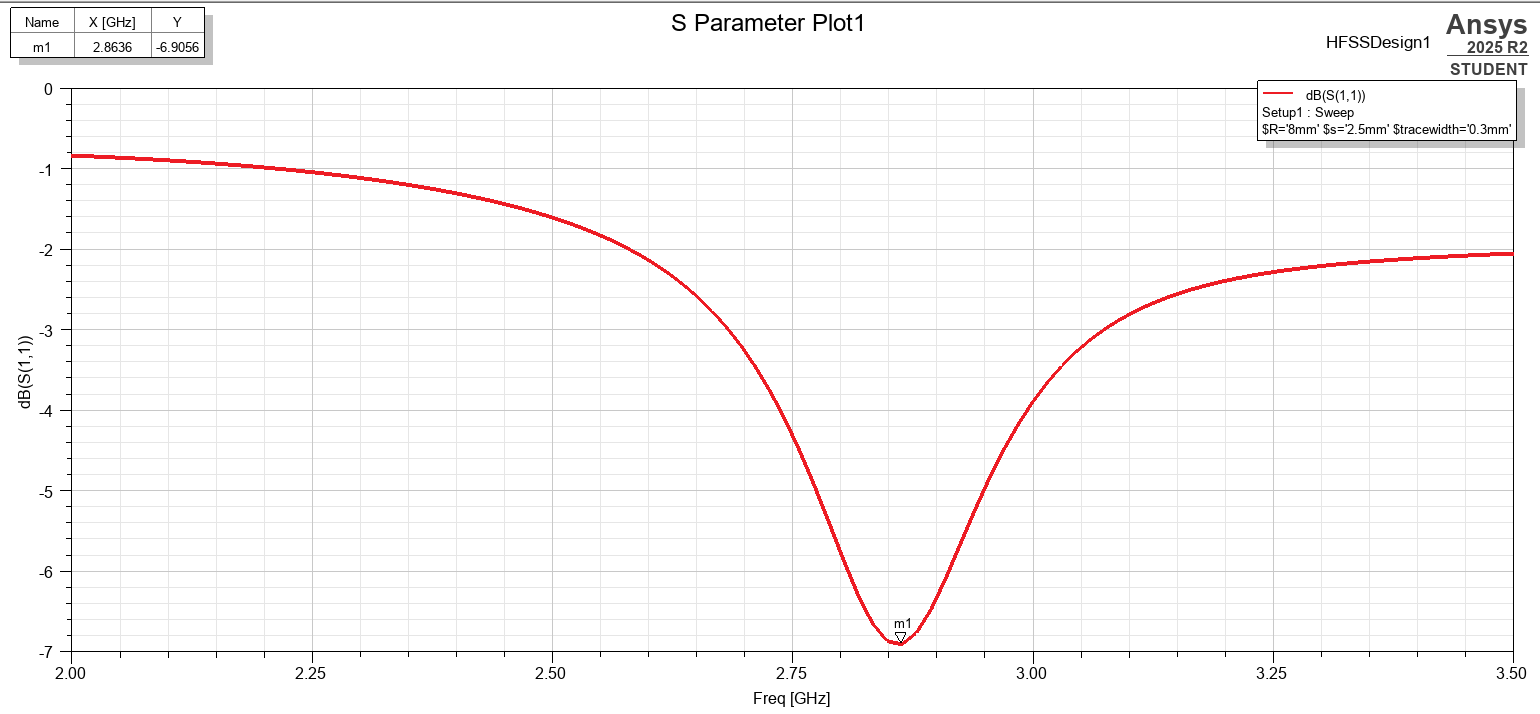

100um
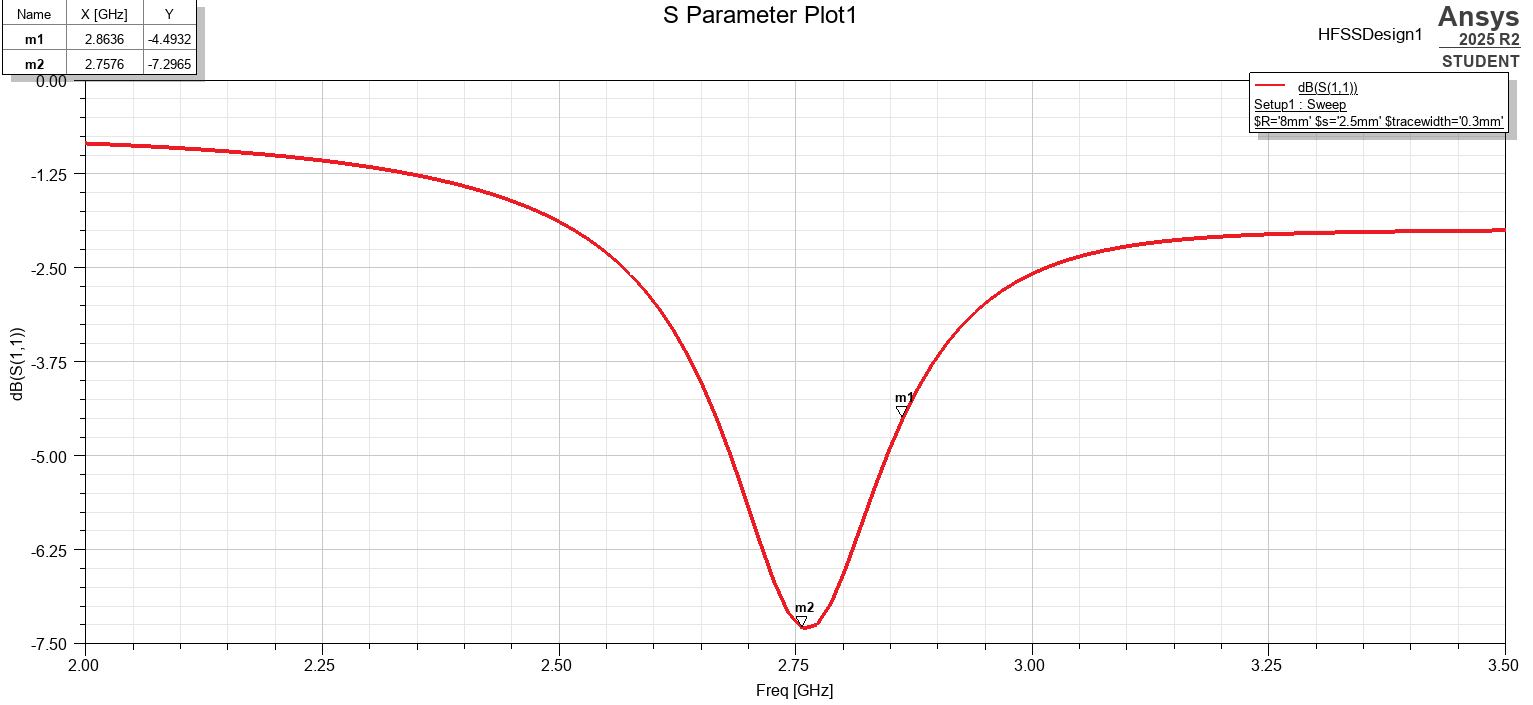

300um
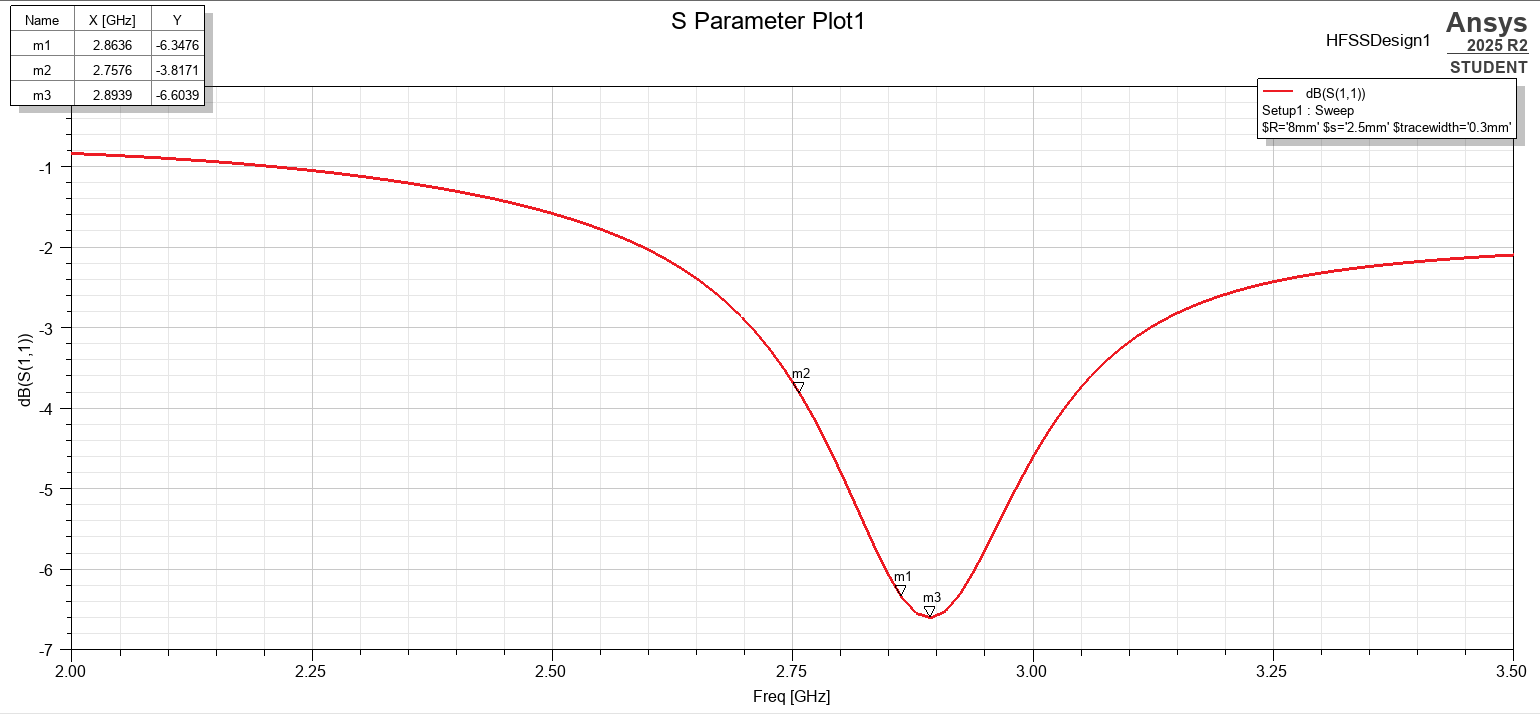

In [3]:
import csv
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

./v2/lumped-port.csv: 100 points, freq range 2-3.5 GHz
./v2/wave-port.csv: 100 points, freq range 2-3.5 GHz


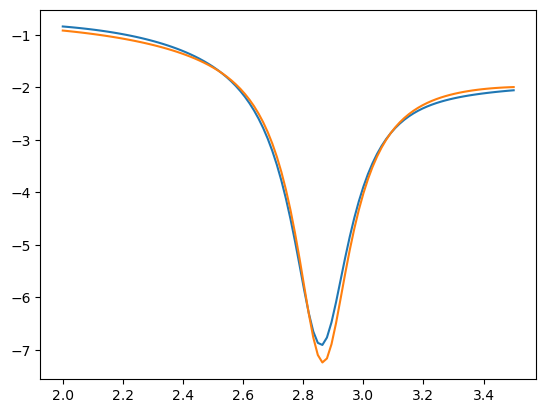

In [5]:


def load_freq_s11(csv_path):
    csv_path = Path(csv_path)

    with csv_path.open(newline="") as f:
        reader = csv.reader(f)
        header = next(reader)

        freq_col = next(i for i, h in enumerate(header) if h.strip().startswith("Freq"))
        s11_col = next(i for i, h in enumerate(header) if h.strip().startswith("dB(S(1,1))"))

        freq, s11 = [], []
        for row in reader:
            if not row:
                continue
            freq.append(float(row[freq_col]))
            s11.append(float(row[s11_col]))

    return np.array(freq), np.array(s11)


if __name__ == "__main__":
    file1 = "./v2/lumped-port.csv"  # replace with actual path
    file2 = "./v2/wave-port.csv"  # replace with actual path

    freq1, s11_1 = load_freq_s11(file1)
    freq2, s11_2 = load_freq_s11(file2)

    fig, ax = plt.subplots()
    ax.plot(freq1, s11_1)
    ax.plot(freq2, s11_2)
    

    print(f"{file1}: {freq1.shape[0]} points, freq range {freq1.min():.4g}-{freq1.max():.4g} GHz")
    print(f"{file2}: {freq2.shape[0]} points, freq range {freq2.min():.4g}-{freq2.max():.4g} GHz")

- from microscope measurements it doesn't seem like the gap is narrowed
- for the resist: dk originally 4.5
- Taiyo PSR-4000BN, tested at 1 MHz 

swept from 2 GHz to 3 GHz with 201 points 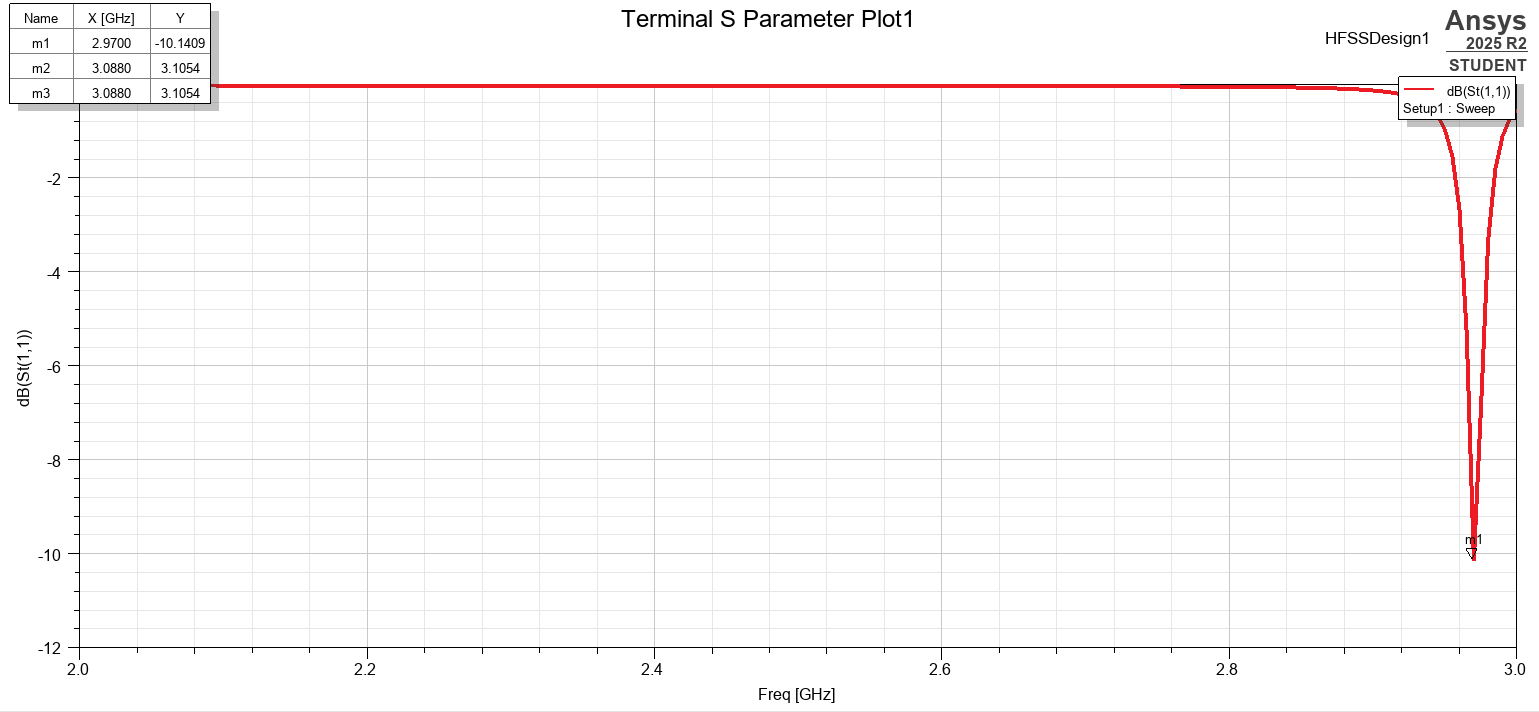
more points: 
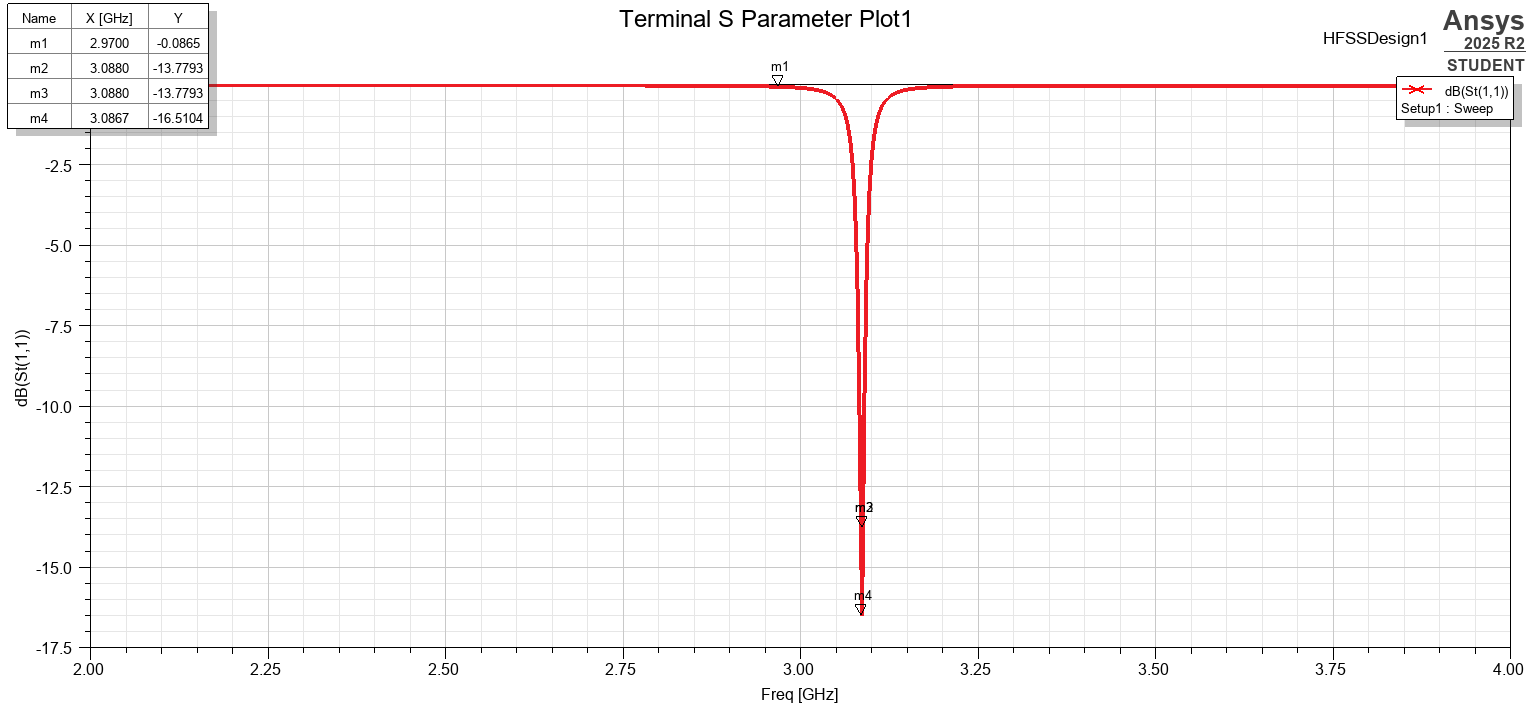

aim for slightly higher frequency rather than lower - different radiuses too, and also tuning

- the position of the ground plane also matters; expand it until making it bigger no longer changes the resonance?
- also a layer of resist on top
- putting diamond does not change as much as predicted?

- make three different boards and aim for different frequencies


no resist, with diamond: 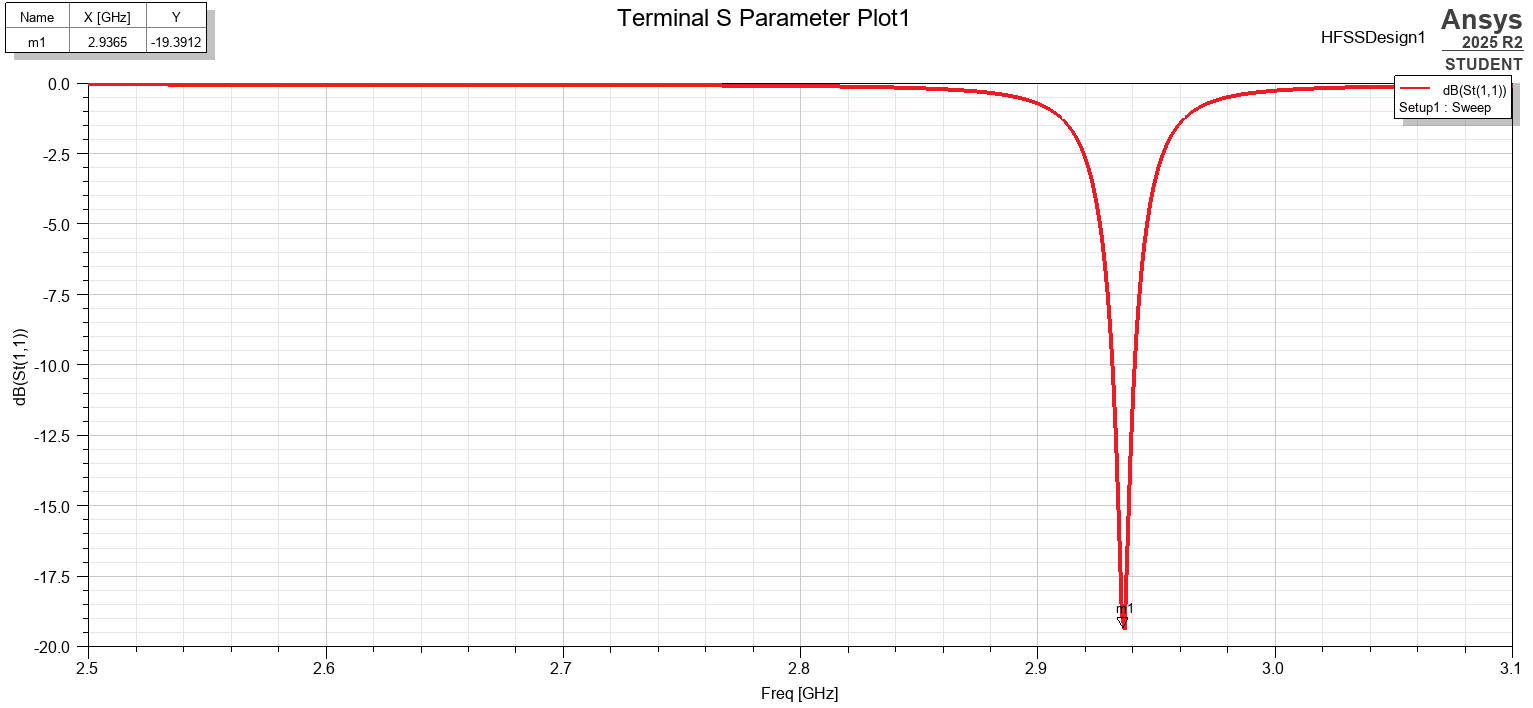

sweeping board width: seem like 20mm is the outlier?
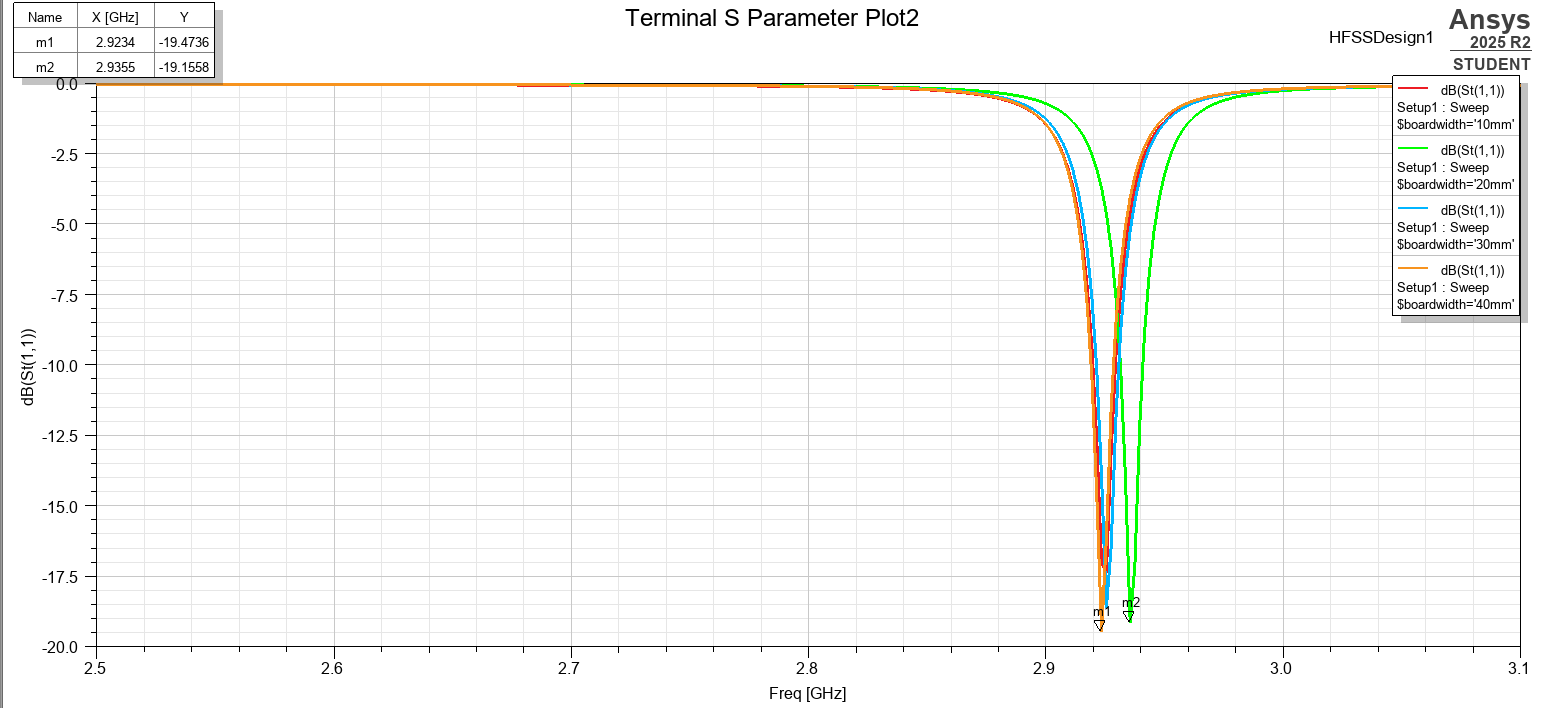

tangent loss: 0.002
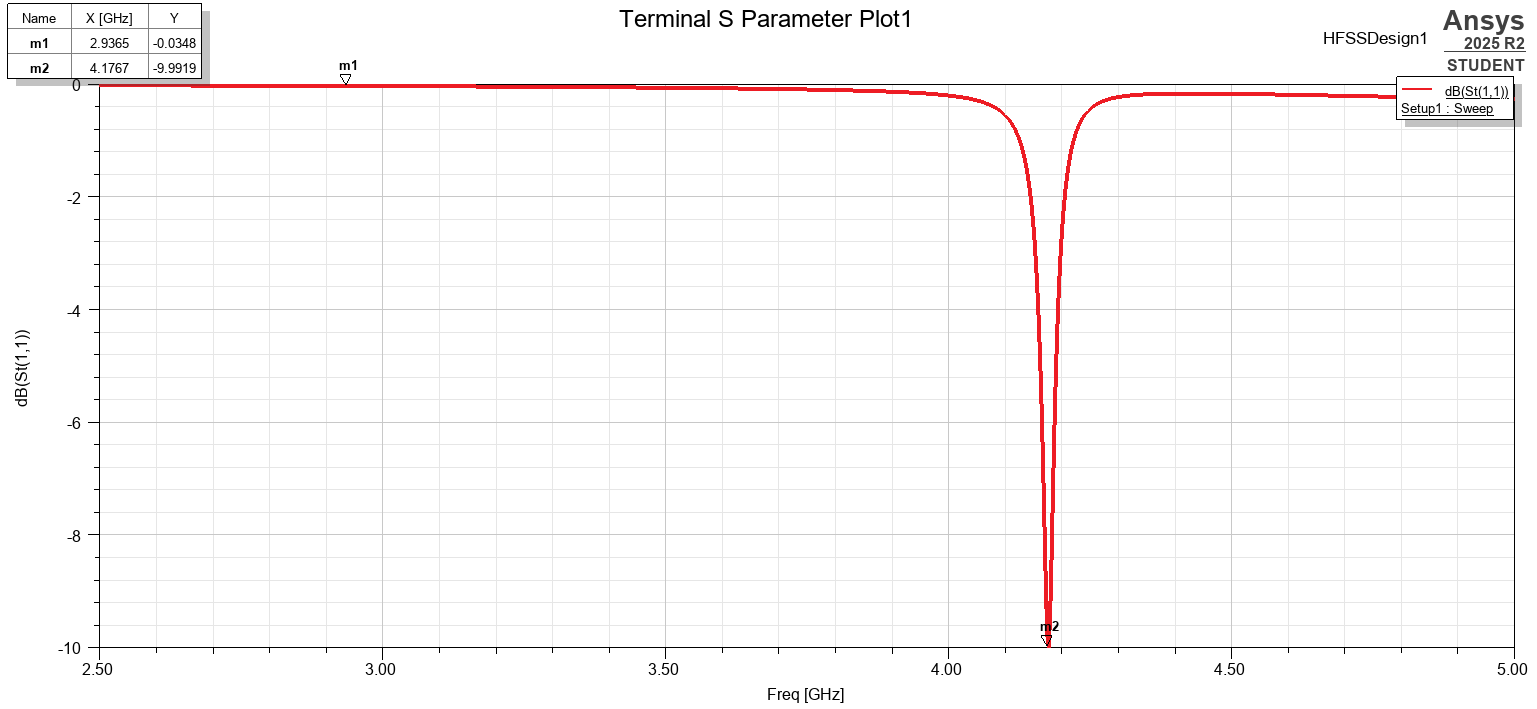